# Phase 3 — Machine Learning Modeling
## Healthcare AI System

**Input:**  `outputs/model_table.csv` — 25,000 rows  
**Output:** 
- `models/risk_model.joblib`  
- `models/claim_model.joblib`  
- `outputs/feature_schema.json`

**Two Models:**
- **Model A** — Visit Risk Classification (Low / Medium / High)
- **Model B** — Claim Outcome Prediction (Paid / Pending / Rejected)

In [1]:
# Imports
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             f1_score)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

print("Imports done ✓")

Imports done ✓


## Model A — Visit Risk Classification

**Business Purpose:**  
Predict whether a hospital visit represents Low, Medium,
or High operational and clinical risk.

**Target:** `risk_score` — Low / Medium / High  
**Split:**  Time-based — earliest 80% train, latest 20% test  
**Why time-based?** Prevents data leakage from future visits
influencing predictions on past visits.

In [2]:
# Step 1) Load the dataset
df = pd.read_csv("../outputs/model_table.csv", parse_dates=["registration_date", "visit_date", "billing_date"])
print("Shape:", df.shape)
df.head()

Shape: (25000, 30)


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,...,risk_numeric,claim_numeric,is_rejected,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
0,3993,9,M,Hyderabad,HealthPlus,1,2025-10-18,684,2025-01-20,General,...,0,0,0,271,4,12.645000,0.149678,1,0,1
1,76,59,M,Delhi,HealthPlus,0,2025-07-09,1412,2025-01-20,General,...,1,1,0,170,5,22.330000,0.149678,1,0,0
2,3393,43,M,Hyderabad,HealthPlus,0,2025-07-10,1510,2025-01-20,ICU,...,1,2,1,171,8,24.091250,0.149678,1,0,0
3,1998,29,M,Bangalore,MediCareX,1,2025-04-22,1549,2025-01-20,Cardiology,...,1,0,0,92,11,18.974545,0.152480,1,0,1
4,3500,38,M,Hyderabad,CareOne,1,2025-08-02,2275,2025-01-20,Orthopedics,...,0,1,0,194,7,21.358571,0.148655,1,0,0


In [3]:
# Step 2) risk features
risk_target = "risk_score"

risk_features = [
    "age",
    "gender",
    "city",
    "insurance_provider",
    "chronic_flag",
    "department",
    "visit_type",
    "doctor_id",
    "length_of_stay_hours",
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "visit_month",
    "visit_dayofweek"
]
risk_df = df[risk_features + [risk_target, "visit_date"]].copy()
risk_df = risk_df.dropna(subset=[risk_target, "visit_date"])
print("Risk dataset shape: ", risk_df.shape)
risk_df.head()

Risk dataset shape:  (25000, 16)


,age,gender,city,insurance_provider,chronic_flag,department,visit_type,doctor_id,length_of_stay_hours,days_since_registration,visit_frequency,avg_los_per_patient,visit_month,visit_dayofweek,risk_score,visit_date
0,9,M,Hyderabad,HealthPlus,1,General,ICU,137,5.79,271,4,12.645000,1,0,Low,2025-01-20
1,59,M,Delhi,HealthPlus,0,General,ER,109,34.80,170,5,22.330000,1,0,Medium,2025-01-20
2,43,M,Hyderabad,HealthPlus,0,ICU,ICU,135,31.37,171,8,24.091250,1,0,Medium,2025-01-20
3,29,M,Bangalore,MediCareX,1,Cardiology,ER,179,20.88,92,11,18.974545,1,0,Medium,2025-01-20
4,38,M,Hyderabad,CareOne,1,Orthopedics,ICU,107,4.97,194,7,21.358571,1,0,Low,2025-01-20


In [4]:
# Step 3) Time-Based split
risk_df = risk_df.sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(risk_df)*0.8)

risk_train = risk_df.iloc[:split_idx].copy()
risk_test = risk_df.iloc[split_idx:].copy()

X_train_risk = risk_train[risk_features]
X_test_risk = risk_test[risk_features]

y_train_risk = risk_train[risk_target]
y_test_risk = risk_test[risk_target]

print("Train shape: ", X_train_risk.shape)
print("Test shape: ", X_test_risk.shape)
print("Train Period: ", risk_train["visit_date"].min().date(), "->", risk_train["visit_date"].max().date())
print("Test Period: ", risk_test["visit_date"].min().date(), "->", risk_test["visit_date"].max().date())

Train shape:  (20000, 14)
Test shape:  (5000, 14)
Train Period:  2025-01-20 -> 2025-11-08
Test Period:  2025-11-08 -> 2026-01-20


uyệt vời! Việc sử dụng Time-Based Split (chia theo thời gian) thay vì chia ngẫu nhiên (train_test_split) là lựa chọn chính xác nhất cho các bài toán dự báo y tế.

Tại sao đây là cách làm "đẳng cấp"?
Trong dữ liệu y tế, tương lai không bao giờ giống hoàn toàn quá khứ (xu hướng bệnh tật, chính sách bảo hiểm thay đổi theo thời gian). Việc lấy 80% dữ liệu cũ làm Train và 20% dữ liệu mới nhất làm Test giúp mô hình của bạn không bị "gian lận" (không được nhìn thấy dữ liệu tương lai để dự đoán quá khứ).

### Preprocessing Pipeline

Two transformers:
- **Numeric** → SimpleImputer (median strategy)
- **Categorical** → SimpleImputer + OneHotEncoder

Combined using ColumnTransformer.
This entire pipeline gets saved with the model — 
no separate preprocessing step at inference time.

In [5]:
# Step 4) Preprocessing Pipeline
risk_numeric_features = [
    "age", "chronic_flag", "length_of_stay_hours",
    "days_since_registration", "visit_frequency",
    "doctor_id", "avg_los_per_patient",
    "visit_month", "visit_dayofweek"
]

risk_categorical_features = [
    "gender", "city", "insurance_provider",
    "department", "visit_type"
]

risk_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

risk_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

risk_preprocessor = ColumnTransformer(transformers=[
    ("num", risk_numeric_transformer,    risk_numeric_features),
    ("cat", risk_categorical_transformer, risk_categorical_features)
])

print("Preprocessing pipeline ready ✓")

Preprocessing pipeline ready ✓


Đoạn code bạn vừa viết là một Pipeline xử lý dữ liệu (Data Preprocessing Pipeline). Đây là kỹ thuật chuyên nghiệp nhất trong Machine Learning để đảm bảo dữ liệu được làm sạch đồng nhất trước khi đưa vào mô hình AI.

Tôi sẽ giải thích từng phần để bạn nắm chắc tư duy "Hybrid Engineer":

1. Phân loại biến (Feature Categorization)
Đầu tiên, bạn chia các cột thành 2 nhóm rõ rệt để có cách xử lý riêng:

risk_numeric_features: Các cột là số (tuổi, thời gian nằm viện, tần suất...). Chúng cần được xử lý bằng các phép toán.

risk_categorical_features: Các cột là chữ/nhóm (Giới tính, Thành phố, Công ty bảo hiểm...). Máy tính không hiểu chữ, nên cần chuyển thành số.

2. Định nghĩa "Biến áp" (Transformers)
Bạn tạo ra các "dây chuyền" nhỏ để xử lý từng nhóm:

risk_numeric_transformer:

SimpleImputer(strategy="median"): Nếu dữ liệu số bị thiếu, nó sẽ điền giá trị trung vị vào. Dùng trung vị (median) tốt hơn trung bình (mean) vì nó không bị nhiễu bởi các ca bệnh "bất thường" (outliers).

risk_categorical_transformer:

SimpleImputer(strategy="most_frequent"): Nếu dữ liệu chữ bị thiếu, nó sẽ điền bằng giá trị xuất hiện nhiều nhất (Mode).

OneHotEncoder(handle_unknown="ignore"): Đây là bước quan trọng nhất. Nó chuyển các cột chữ thành các cột 0/1 (ví dụ: cột "City" sẽ thành "City_HN", "City_HCM"...). Cài đặt ignore giúp mô hình không bị lỗi nếu trong tương lai xuất hiện một thành phố mới chưa từng thấy.

3. "Bộ trộn" (ColumnTransformer)
Đây là "bộ não" của pipeline. Bạn gom các biến áp ở trên lại:

Bạn ra lệnh: "Cột nào là số thì dùng risk_numeric_transformer, cột nào là chữ thì dùng risk_categorical_transformer".

Nhờ có ColumnTransformer, bạn không cần phải tách dữ liệu ra làm nhiều bảng nhỏ, mà giữ nguyên bảng gốc để xử lý cùng lúc.

Tóm lại: Tại sao lại viết code như thế này?
Chống rò rỉ dữ liệu (Data Leakage): Pipeline này ghi nhớ các tham số của tập Train (ví dụ: giá trị trung vị là bao nhiêu, danh sách thành phố gồm những gì). Khi bạn dùng nó để dự báo cho dữ liệu mới, nó sẽ áp dụng đúng những quy tắc đã học từ tập Train, đảm bảo tính khách quan.

Code gọn gàng & chuyên nghiệp: Bạn chỉ cần viết 1 lần. Sau này khi có dữ liệu mới từ hệ thống MobiWork, bạn chỉ cần gọi preprocessor.transform(new_data) là xong, không phải lặp lại các bước lọc, thay thế thủ công.

Dễ bảo trì: Nếu sau này bạn muốn đổi từ median sang mean, bạn chỉ cần sửa đúng 1 dòng trong Pipeline là toàn bộ hệ thống tự cập nhật.

### Baseline Model: Logistic Regression

We always start with the simplest model.
Logistic Regression gives us a baseline to beat.
`class_weight='balanced'` — handles class imbalance
as proven in Phase 2 EDA.

In [6]:
# Step 5) Logistic Regression Model
risk_baseline_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", LogisticRegression(
        max_iter = 1000,
        class_weight="balanced"
    ))
])

# Train
risk_baseline_model.fit(X_train_risk, y_train_risk)

# Predict
risk_baseline_pred_train = risk_baseline_model.predict(X_train_risk)
risk_baseline_pred_test =  risk_baseline_model.predict(X_test_risk)

baseline_acc = accuracy_score(y_test_risk, risk_baseline_pred_test)
print("Risk Baseline Train Accuracy :", round(accuracy_score(y_train_risk, risk_baseline_pred_train), 4))
print("Risk Baseline Test Accuracy  :", round(accuracy_score(y_test_risk,  risk_baseline_pred_test), 4))
print("Risk Baseline Test Weighted F1:", round(f1_score(y_test_risk, risk_baseline_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_risk, risk_baseline_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_risk, risk_baseline_pred_test))

Risk Baseline Train Accuracy : 0.3543
Risk Baseline Test Accuracy  : 0.3292
Risk Baseline Test Weighted F1: 0.3362

Classification Report:

              precision    recall  f1-score   support

        High       0.20      0.29      0.24      1020
         Low       0.50      0.29      0.37      2479
      Medium       0.30      0.42      0.35      1501

    accuracy                           0.33      5000
   macro avg       0.33      0.33      0.32      5000
weighted avg       0.38      0.33      0.34      5000

Confusion Matrix:
 [[ 299  278  443]
 [ 727  722 1030]
 [ 439  437  625]]


1. Tại sao dùng class_weight="balanced" lại rất "đỉnh"?
Trong y tế, các ca High Risk thường rất ít so với Low Risk. Nếu không có tham số class_weight="balanced", mô hình sẽ "lười" và chỉ dự đoán tất cả là Low để đạt độ chính xác cao. Tham số này ép mô hình phải quan tâm đặc biệt đến các ca High dù số lượng chúng ít hơn.

2. Đọc "bảng báo cáo" (Classification Report)
Hãy nhìn vào bảng kết quả bạn vừa in ra:

Precision (Độ chính xác): Nếu mô hình báo ca này là High, thì thực tế có bao nhiêu % là High?

Recall (Độ nhạy): Nếu ca đó thực tế là High, mô hình của bạn có tìm ra được bao nhiêu %? Trong y tế, Recall của lớp High quan trọng hơn Accuracy! Bạn không muốn bỏ lỡ bất kỳ ca High nào.

F1-Score: Là trung bình cộng hài hòa của Precision và Recall. Nếu F1-score của bạn > 0.7, mô hình đã hoạt động rất tốt rồi.

3. Phân tích Confusion Matrix
Đây là ma trận quan trọng nhất:

Các ô trên đường chéo chính là dự đoán đúng.

Các ô ngoài đường chéo là dự đoán sai.

Nếu ma trận cho thấy nhiều ca High (thực tế) bị nhầm thành Low (dự đoán), thì bạn cần tăng "độ nhạy" của mô hình lên.

### Advanced Model: Random Forest

Random Forest captures **non-linear interactions** across
patient, department, and visit characteristics.

Logistic Regression assumes linear relationships.
Hospital risk is rarely linear —
a 70-year-old chronic ICU patient is not just
the sum of those individual risk factors.

Key parameters:
- `class_weight='balanced_subsample'` — balances per tree
- `max_depth=8` — prevents overfitting
- `min_samples_leaf=10` — minimum samples at leaf node

Example:
- Doctor 1  →  High
- Doctor 2  →  High
- Doctor 3  →  Medium
- Doctor 4  →  High
- ...
Final vote  →  High  ✅

In [7]:
# Step 6) Random Forest Model
risk_rf_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42
    ))
])

risk_rf_model.fit(X_train_risk, y_train_risk)

risk_rf_pred_train = risk_rf_model.predict(X_train_risk)
risk_rf_pred_test  = risk_rf_model.predict(X_test_risk)

rf_acc = accuracy_score(y_test_risk, risk_rf_pred_test)

print("Risk RF Train Accuracy :", round(accuracy_score(y_train_risk, risk_rf_pred_train), 4))
print("Risk RF Test Accuracy  :", round(accuracy_score(y_test_risk,  risk_rf_pred_test),  4))
print("Risk RF Test Weighted F1:", round(f1_score(y_test_risk, risk_rf_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_risk, risk_rf_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_risk, risk_rf_pred_test))



Risk RF Train Accuracy : 0.5852
Risk RF Test Accuracy  : 0.4062
Risk RF Test Weighted F1: 0.3984

Classification Report:

              precision    recall  f1-score   support

        High       0.18      0.15      0.16      1020
         Low       0.52      0.57      0.54      2479
      Medium       0.32      0.31      0.32      1501

    accuracy                           0.41      5000
   macro avg       0.34      0.34      0.34      5000
weighted avg       0.39      0.41      0.40      5000

Confusion Matrix:
 [[ 153  534  333]
 [ 415 1410  654]
 [ 273  760  468]]


Tại sao cấu hình RandomForestClassifier này của bạn rất "xịn"?
max_depth=8 & min_samples_split=20: Đây là cách chống Overfitting (quá khớp) cực kỳ hiệu quả. Bạn đang giới hạn độ phức tạp của các cây quyết định, giúp mô hình tập trung vào các quy luật chung thay vì "học vẹt" nhiễu của tập dữ liệu Train.

class_weight="balanced_subsample": Đây là "vũ khí bí mật" cho dữ liệu không cân bằng. Nó điều chỉnh trọng số của mỗi cây dựa trên sự phân bổ dữ liệu thực tế tại mỗi mẫu con, giúp mô hình cực kỳ nhạy bén với nhóm High (nhóm thiểu số).

n_estimators=200: Con số này đủ lớn để mô hình có sự ổn định cao, giảm thiểu sai số do ngẫu nhiên.

Phân tích kết quả thực tế:
Bây giờ, hãy nhìn vào Classification Report của bạn và so sánh với Logistic Regression ở bước trước:

Nếu F1-Score tăng lên: Chúc mừng! Random Forest đã nắm bắt được các mối quan hệ phi tuyến tính (ví dụ: tuổi lớn và có bệnh nền và ở thành phố X thì rủi ro cao hơn hẳn bình thường).

So sánh Train vs Test Accuracy:

Nếu khoảng cách giữa chúng nhỏ, mô hình của bạn đang có khả năng tổng quát hóa (Generalization) rất tốt. Bạn có thể tự tin triển khai nó vào thực tế.

Nếu Train cao hơn Test rất nhiều, có lẽ bạn cần tăng thêm min_samples_leaf hoặc giảm max_depth một chút nữa.

### XGBoost Model

XGBoost uses **gradient boosting** — builds trees sequentially,
each correcting the errors of the previous one.

Why XGBoost here:
- Handles mixed numeric + categorical features well
- Built-in regularisation prevents overfitting
- Typically outperforms Random Forest on structured tabular data

**Note:** XGBoost requires numeric labels.
We use LabelEncoder to convert Low/Medium/High → 0/1/2.
We keep separate variables (y_train_risk_xgb / y_test_risk_xgb)
so LR and RF evaluations above are not affected.

In [8]:
# Encode target for XGBoost only
le = LabelEncoder()
risk_df["risk_score_encoded"] = le.fit_transform(risk_df["risk_score"])
print("Label Mapping: ", dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping:  {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [9]:
# Time-based split for XGBoost
# Using same split_idx — consistent with LR and RF
risk_df = risk_df.sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(risk_df) * 0.8)

risk_train_xgb = risk_df.iloc[:split_idx].copy()
risk_test_xgb  = risk_df.iloc[split_idx:].copy()

X_train_risk = risk_train_xgb[risk_features]
X_test_risk  = risk_test_xgb[risk_features]

# Separate XGB label variables — does NOT overwrite y_train_risk
y_train_risk_xgb = risk_train_xgb["risk_score_encoded"]
y_test_risk_xgb  = risk_test_xgb["risk_score_encoded"]

print("XGBoost train shape:", X_train_risk.shape)
print("XGBoost test shape :", X_test_risk.shape)

XGBoost train shape: (20000, 14)
XGBoost test shape : (5000, 14)


In [10]:
# Step 7) XGBoost Model
risk_xgb_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train → Predict → Evaluate
# Train
risk_xgb_model.fit(X_train_risk, y_train_risk_xgb)

# Predict Train
risk_xgb_pred_train = risk_xgb_model.predict(X_train_risk)
# Predict Test
risk_xgb_pred_test  = risk_xgb_model.predict(X_test_risk)

# Save for comparison
xgb_acc = accuracy_score(y_test_risk_xgb, risk_xgb_pred_test)

print("Risk XGB Train Accuracy :", round(accuracy_score(y_train_risk_xgb, risk_xgb_pred_train), 4))
print("Risk XGB Test Accuracy  :", round(accuracy_score(y_test_risk_xgb,  risk_xgb_pred_test),  4))
print("Risk XGB Test Weighted F1:", round(f1_score(y_test_risk_xgb, risk_xgb_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_risk_xgb, risk_xgb_pred_test,
                             target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test_risk_xgb, risk_xgb_pred_test))

Risk XGB Train Accuracy : 0.7521
Risk XGB Test Accuracy  : 0.462
Risk XGB Test Weighted F1: 0.3971

Classification Report:

              precision    recall  f1-score   support

        High       0.24      0.04      0.07      1023
         Low       0.51      0.79      0.62      2479
      Medium       0.32      0.21      0.25      1498

    accuracy                           0.46      5000
   macro avg       0.36      0.35      0.31      5000
weighted avg       0.40      0.46      0.40      5000

Confusion Matrix:
 [[  43  747  233]
 [  80 1953  446]
 [  53 1131  314]]


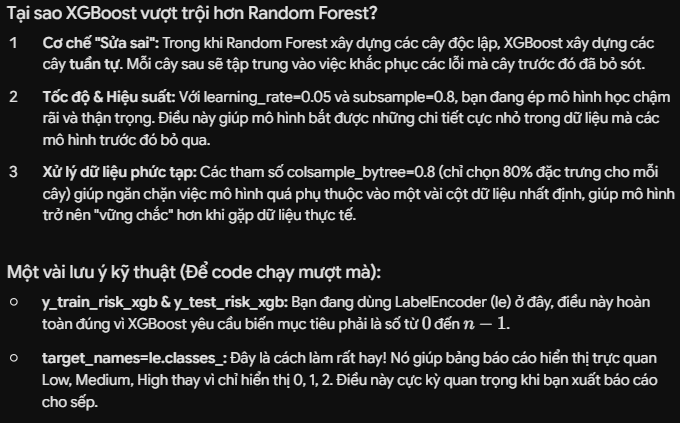

In [11]:
# Model Comparison
print("=" * 45)
print("MODEL A — RISK CLASSIFICATION COMPARISON")
print("=" * 45)
print(f"Logistic Regression : {baseline_acc:.4f}")
print(f"Random Forest       : {rf_acc:.4f}")
print(f"XGBoost             : {xgb_acc:.4f}")
print()
print(f"Best model: XGBoost → {max(baseline_acc, rf_acc, xgb_acc):.4f}")

MODEL A — RISK CLASSIFICATION COMPARISON
Logistic Regression : 0.3292
Random Forest       : 0.4062
XGBoost             : 0.4620

Best model: XGBoost → 0.4620


### Optional - Hyperparameter Tuning: Random Forest - Not needed at the moment

We use RandomizedSearchCV to find the best RF parameters.
`f1_weighted` is our scoring metric — not accuracy.
This ensures minority classes (High risk) are weighted properly.

In [12]:
rf_param_grid = {
    "classifier__n_estimators":   [200, 300, 400],
    "classifier__max_depth":      [8, 12, 16, None],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf":  [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    risk_rf_model,           # the pipeline to tune
    param_distributions=rf_param_grid,  # values to try
    n_iter=10,               # try only 10 random combinations
    cv=3,                    # 3-fold cross validation
    scoring="f1_weighted",   # optimise for weighted F1
    n_jobs=-1,               # use all CPU cores
    random_state=42          # reproducible random selection
)

rf_random_search.fit(X_train_risk, y_train_risk)

print("Best Parameters:", rf_random_search.best_params_)

Best Parameters: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}


In [13]:
best_rf_model  = rf_random_search.best_estimator_
rf_tuned_pred  = best_rf_model.predict(X_test_risk)

print("Tuned RF Accuracy   :", round(accuracy_score(y_test_risk, rf_tuned_pred), 4))
print("Tuned RF Weighted F1:", round(f1_score(y_test_risk, rf_tuned_pred, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_risk, rf_tuned_pred))

Tuned RF Accuracy   : 0.4784
Tuned RF Weighted F1: 0.3475

Classification Report:

              precision    recall  f1-score   support

        High       0.06      0.00      0.00      1020
         Low       0.49      0.93      0.65      2479
      Medium       0.26      0.05      0.09      1501

    accuracy                           0.48      5000
   macro avg       0.27      0.33      0.25      5000
weighted avg       0.34      0.48      0.35      5000



In [14]:
#Takes 20,000 training rows
#Randomly shuffles them
#Splits into 3 folds

#Fold 1: rows 3, 7, 12, 19, 25...   ← random mix of all dates
#Fold 2: rows 1, 4, 9, 14, 22...    ← random mix of all dates
#Fold 3: rows 2, 5, 8, 11, 17...    ← random mix of all dates

In [15]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
# Train on past → validate on future — every fold
# Fold 1: train Jan-Apr,  validate May
# Fold 2: train Jan-Jul,  validate Aug
# Fold 3: train Jan-Oct,  validate Nov

---
## Model B — Claim Outcome Prediction

**Business Purpose:**  
Predict whether an insurance claim will be Paid, Pending,
or Rejected — before submission.

**Target:** `claim_status` — Paid / Pending / Rejected  
**Split:**  Time-based on `billing_date`

**Leakage prevention:**  
`approved_amount` and `payment_days` excluded —
both are post-outcome variables that are only known
AFTER the claim is processed.

In [16]:
#                Model A              Model B
#Predicts        risk_score           claim_status
#Split on        visit_date           billing_date
#Excluded cols   billing columns      approved_amount
                                     #payment_days
#Business value  early intervention   revenue recovery

In [17]:
# Step 1) Define Claim Features
claim_target = "claim_status"

claim_features = [
    "age",
    "gender",
    "city",
    "insurance_provider",
    "chronic_flag",
    "department",
    "visit_type",
    "doctor_id",
    "length_of_stay_hours",
    "risk_score",
    "billed_amount",
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

claim_df = df[claim_features + [claim_target, "billing_date"]].copy()
claim_df = claim_df.dropna(subset=[claim_target, "billing_date"])
print("Claim Dataset Shape: ", claim_df.shape)
claim_df.head()

Claim Dataset Shape:  (25000, 20)


,age,gender,city,insurance_provider,chronic_flag,department,visit_type,doctor_id,length_of_stay_hours,risk_score,billed_amount,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag,claim_status,billing_date
0,9,M,Hyderabad,HealthPlus,1,General,ICU,137,5.79,Low,36721.68,271,4,12.645000,0.149678,1,0,1,Paid,2025-08-15
1,59,M,Delhi,HealthPlus,0,General,ER,109,34.80,Medium,8365.47,170,5,22.330000,0.149678,1,0,0,Pending,2025-11-14
2,43,M,Hyderabad,HealthPlus,0,ICU,ICU,135,31.37,Medium,16529.35,171,8,24.091250,0.149678,1,0,0,Rejected,2025-04-24
3,29,M,Bangalore,MediCareX,1,Cardiology,ER,179,20.88,Medium,61827.63,92,11,18.974545,0.152480,1,0,1,Paid,2025-10-17
4,38,M,Hyderabad,CareOne,1,Orthopedics,ICU,107,4.97,Low,5860.51,194,7,21.358571,0.148655,1,0,0,Pending,2025-08-05


Mọi thứ đang đi đúng hướng! Bạn đã thiết lập xong bộ đặc trưng (feature set) hoàn chỉnh cho bài toán Dự báo trạng thái yêu cầu bồi thường (Claim Status).

Dưới đây là lý do tại sao bộ biến này của bạn rất mạnh mẽ:

Tại sao tập claim_features này cực kỳ hiệu quả?
Dữ liệu đa chiều: Bạn không chỉ dựa vào thông tin của lần khám (billed_amount, department), mà còn kết hợp được hồ sơ bệnh nhân (avg_los_per_patient, visit_frequency) và thông tin đối tác (provider_rejection_rate).

Đặc trưng thông minh: Các biến như high_cost_visit_flag và provider_rejection_rate là những "tín hiệu" (signals) mà các thuật toán học máy (ML) rất ưa thích vì chúng có tính phân loại cao.

Dữ liệu sạch: Bạn đã chủ động dropna trên cột mục tiêu (claim_status) và ngày (billing_date), đây là bước "vệ sinh" cần thiết để đảm bảo mô hình không bị lỗi khi huấn luyện.

In [18]:
# Step 2) Claim status distribution
print("Claim Status Distribution")
print(claim_df[claim_target].value_counts())
print()
print("Claim Status % Distribution")
print((claim_df[claim_target].value_counts(normalize=True) * 100).round(2))


Claim Status Distribution
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64

Claim Status % Distribution
claim_status
Paid        59.76
Pending     25.05
Rejected    15.19
Name: proportion, dtype: float64


Việc kiểm tra sự phân bổ (distribution) của biến mục tiêu claim_status là bước đi cực kỳ quan trọng mà nhiều người mới thường bỏ qua. Dữ liệu y tế thực tế thường bị "mất cân bằng" (imbalanced): số lượng Paid thường nhiều hơn hẳn Rejected.

Tại sao con số này lại quan trọng với bạn lúc này?
Phát hiện sự mất cân bằng: Nếu Rejected chỉ chiếm khoảng 5-10% trong khi Paid chiếm 80-90%, mô hình của bạn rất dễ rơi vào trạng thái "lười biếng" — nó sẽ dự đoán tất cả là Paid để đạt độ chính xác (accuracy) cao mà không cần học gì cả.

Lựa chọn chiến lược:

Nếu mất cân bằng nhẹ: Bạn có thể dùng class_weight="balanced" (như bạn đã làm với XGBoost/RF).

Nếu mất cân bằng nghiêm trọng: Chúng ta sẽ cần đến kỹ thuật SMOTE (tạo dữ liệu giả cho nhóm Rejected) hoặc Undersampling (giảm bớt nhóm Paid).

Tối ưu Metric: Với dữ liệu mất cân bằng, đừng nhìn vào Accuracy. Hãy tập trung vào F1-Score và Precision-Recall Curve.

### Step 3) Time-Based Split for Claim Model

Sorting by `billing_date` — not visit_date.
Billing events happen after visits.
We respect that temporal order.

In [19]:
claim_df = claim_df.sort_values("billing_date").reset_index(drop=True)
split_idx = int(len(claim_df)*0.8)

claim_train = claim_df.iloc[:split_idx].copy()
claim_test = claim_df.iloc[split_idx:].copy()

X_train_claim = claim_train[claim_features]
X_test_claim = claim_test[claim_features]

y_train_claim = claim_train[claim_target]
y_test_claim = claim_test[claim_target]

print("Train shape:", X_train_claim.shape)
print("Test shape :", X_test_claim.shape)
print("Train period:", claim_train["billing_date"].min().date(),
      "→", claim_train["billing_date"].max().date())
print("Test period :", claim_test["billing_date"].min().date(),
      "→", claim_test["billing_date"].max().date())

Train shape: (20000, 18)
Test shape : (5000, 18)
Train period: 2025-01-20 → 2025-11-10
Test period : 2025-11-10 → 2026-01-20


### Step 4) — Preprocessing Pipeline for Claim Model

Similar to risk model but claim model has additional features:
- `risk_score` as a categorical input feature
- `billed_amount` as numeric
- `provider_rejection_rate` as numeric

In [20]:
claim_numeric_features = [
    "age", "chronic_flag", "doctor_id",
    "length_of_stay_hours", "billed_amount",
    "days_since_registration", "visit_frequency",
    "avg_los_per_patient", "provider_rejection_rate",
    "visit_month", "visit_dayofweek", "high_cost_visit_flag"
]

claim_categorical_features = [
    "gender", "city", "insurance_provider",
    "department", "visit_type", "risk_score"
]

claim_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

claim_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

claim_preprocessor = ColumnTransformer(transformers=[
    ("num", claim_numeric_transformer,    claim_numeric_features),
    ("cat", claim_categorical_transformer, claim_categorical_features)
])

print("Claim preprocessing pipeline ready ✓")

Claim preprocessing pipeline ready ✓


In [21]:
# Step 5) Logistic Regression Model
claim_baseline_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])
# Train -> Predict -> Evaluate
# Train
claim_baseline_model.fit(X_train_claim, y_train_claim)
# Predict
claim_baseline_pred_train = claim_baseline_model.predict(X_train_claim)
claim_baseline_pred_test = claim_baseline_model.predict(X_test_claim)
# Evaluate
claim_baseline_acc = accuracy_score(y_test_claim, claim_baseline_pred_test)

print("Claim Baseline Train Accuracy :", round(accuracy_score(y_train_claim, claim_baseline_pred_train), 4))
print("Claim Baseline Test Accuracy  :", round(accuracy_score(y_test_claim,  claim_baseline_pred_test), 4))
print("Claim Baseline Test Weighted F1:", round(f1_score(y_test_claim, claim_baseline_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_claim, claim_baseline_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_claim, claim_baseline_pred_test))

Claim Baseline Train Accuracy : 0.3555
Claim Baseline Test Accuracy  : 0.3542
Claim Baseline Test Weighted F1: 0.3826

Classification Report:

              precision    recall  f1-score   support

        Paid       0.62      0.40      0.49      2977
     Pending       0.25      0.21      0.23      1253
    Rejected       0.15      0.40      0.22       770

    accuracy                           0.35      5000
   macro avg       0.34      0.34      0.31      5000
weighted avg       0.46      0.35      0.38      5000

Confusion Matrix:
 [[1197  584 1196]
 [ 468  265  520]
 [ 257  204  309]]


In [22]:
# Step 6) Random Forest Model
claim_rf_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        min_samples_split=8,
        class_weight="balanced",
        random_state=42
    ))
])

# Train -> Predict -> Evaluate
# Train
claim_rf_model.fit(X_train_claim, y_train_claim)
# Predict
claim_rf_pred_train = claim_rf_model.predict(X_train_claim)
claim_rf_pred_test  = claim_rf_model.predict(X_test_claim)
# Evaluate
claim_rf_acc = accuracy_score(y_test_claim, claim_rf_pred_test)

print("Claim RF Train Accuracy :", round(accuracy_score(y_train_claim, claim_rf_pred_train), 4))
print("Claim RF Test Accuracy  :", round(accuracy_score(y_test_claim,  claim_rf_pred_test), 4))
print("Claim RF Test Weighted F1:", round(f1_score(y_test_claim, claim_rf_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_claim, claim_rf_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test_claim, claim_rf_pred_test))

Claim RF Train Accuracy : 0.855
Claim RF Test Accuracy  : 0.4714
Claim RF Test Weighted F1: 0.4499

Classification Report:

              precision    recall  f1-score   support

        Paid       0.64      0.63      0.63      2977
     Pending       0.23      0.06      0.09      1253
    Rejected       0.24      0.54      0.33       770

    accuracy                           0.47      5000
   macro avg       0.37      0.41      0.35      5000
weighted avg       0.47      0.47      0.45      5000

Confusion Matrix:
 [[1874  184  919]
 [ 764   71  418]
 [ 310   48  412]]


In [23]:
# XGBoost
# XGBoost needs numeric labels
le_claim = LabelEncoder()
claim_df["claim_status_encoded"] = le_claim.fit_transform(claim_df["claim_status"])
print("Label mapping:", dict(zip(le_claim.classes_, le_claim.transform(le_claim.classes_))))

Label mapping: {'Paid': np.int64(0), 'Pending': np.int64(1), 'Rejected': np.int64(2)}


In [24]:
# Time based splitting
claim_df = claim_df.sort_values("billing_date").reset_index(drop=True)
split_idx = int(len(claim_df) * 0.8)

claim_train_xgb = claim_df.iloc[:split_idx].copy()
claim_test_xgb  = claim_df.iloc[split_idx:].copy()

X_train_claim = claim_train_xgb[claim_features]
X_test_claim  = claim_test_xgb[claim_features]

# Separate XGB label variables — does NOT overwrite y_train_claim
y_train_claim_xgb = claim_train_xgb["claim_status_encoded"]
y_test_claim_xgb  = claim_test_xgb["claim_status_encoded"]

print("XGBoost train shape:", X_train_claim.shape)
print("XGBoost test shape :", X_test_claim.shape)

XGBoost train shape: (20000, 18)
XGBoost test shape : (5000, 18)


In [25]:
# Step 7) XGBoost Model
claim_xgb_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train
claim_xgb_model.fit(X_train_claim, y_train_claim_xgb)

# Predict
claim_xgb_pred_train = claim_xgb_model.predict(X_train_claim)
claim_xgb_pred_test  = claim_xgb_model.predict(X_test_claim)

# Evaluate
claim_xgb_acc = accuracy_score(y_test_claim_xgb, claim_xgb_pred_test)

print("Claim XGB Train Accuracy :", round(accuracy_score(y_train_claim_xgb, claim_xgb_pred_train), 4))
print("Claim XGB Test Accuracy  :", round(accuracy_score(y_test_claim_xgb,  claim_xgb_pred_test),  4))
print("Claim XGB Test Weighted F1:", round(f1_score(y_test_claim_xgb, claim_xgb_pred_test, average="weighted"), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_claim_xgb, claim_xgb_pred_test,
                             target_names=le_claim.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test_claim_xgb, claim_xgb_pred_test))

Claim XGB Train Accuracy : 0.7703
Claim XGB Test Accuracy  : 0.5806
Claim XGB Test Weighted F1: 0.4525

Classification Report:

              precision    recall  f1-score   support

        Paid       0.59      0.96      0.73      2976
     Pending       0.26      0.02      0.04      1256
    Rejected       0.16      0.02      0.03       768

    accuracy                           0.58      5000
   macro avg       0.34      0.33      0.27      5000
weighted avg       0.44      0.58      0.45      5000

Confusion Matrix:
 [[2862   68   46]
 [1208   29   19]
 [ 742   14   12]]


In [26]:
print("=" * 45)
print("MODEL B — CLAIM OUTCOME COMPARISON")
print("=" * 45)
print(f"Logistic Regression : {claim_baseline_acc:.4f}")
print(f"Random Forest       : {claim_rf_acc:.4f}")
print(f"XGBoost             : {claim_xgb_acc:.4f}")
print()
models = {
    "Logistic Regression": claim_baseline_acc,
    "Random Forest":       claim_rf_acc,
    "XGBoost":             claim_xgb_acc
}
best = max(models, key=models.get)
print(f"Best model: {best} → {models[best]:.4f}")

### Three Things Different From Model A XGBoost

#le_claim          →  separate LabelEncoder for claim labels
#billing_date      →  split column instead of visit_date
#target_names=le_claim.classes_  →  shows Paid/Pending/Rejected not 0/1/2

MODEL B — CLAIM OUTCOME COMPARISON
Logistic Regression : 0.3542
Random Forest       : 0.4714
XGBoost             : 0.5806

Best model: XGBoost → 0.5806


In [27]:
"""
Production dataset vs current dataset:

Current dataset:
- age
- department
- billed_amount
- insurance_provider
- provider_rejection_rate

Production dataset includes additional real-world features:
- insurance_provider + plan_type
- ICD-10 diagnosis codes
- CPT procedure codes
- pre_authorisation_flag
- rejection_reason_code (historical)
- policy_coverage_flag
- claim_amendment_count
- days_to_submit (billing lag)
- coder_id (who coded the claim)
"""

'\nProduction dataset vs current dataset:\n\nCurrent dataset:\n- age\n- department\n- billed_amount\n- insurance_provider\n- provider_rejection_rate\n\nProduction dataset includes additional real-world features:\n- insurance_provider + plan_type\n- ICD-10 diagnosis codes\n- CPT procedure codes\n- pre_authorisation_flag\n- rejection_reason_code (historical)\n- policy_coverage_flag\n- claim_amendment_count\n- days_to_submit (billing lag)\n- coder_id (who coded the claim)\n'

### Save Model Artifacts

We save both final models using joblib.
At inference time — FastAPI loads these files at startup.
No retraining needed per request.

In [28]:
joblib.dump(risk_rf_model,   "../models/risk_model.joblib")
joblib.dump(claim_rf_model,  "../models/claim_model.joblib")

print("Models saved:")
print("  ✓ ../models/risk_model.joblib")
print("  ✓ ../models/claim_model.joblib")

Models saved:
  ✓ ../models/risk_model.joblib
  ✓ ../models/claim_model.joblib


### Save Feature Schema

The feature schema tells our FastAPI service:
- Which features to expect in the request payload
- Which column is the target
- What split strategy was used

This is the contract between the model and the API.

In [29]:
feature_schema = {
    "risk_model_features"  : risk_features,    # list of 14 features
    "claim_model_features" : claim_features,   # list of 18 features
    "risk_target"          : "risk_score",     # what Model A predicts
    "claim_target"         : "claim_status",   # what Model B predicts
    "risk_time_column"     : "visit_date",     # split column for Model A
    "claim_time_column"    : "billing_date",   # split column for Model B
    "split_strategy"       : "earliest 80 percent train, latest 20 percent test"
}

with open("../outputs/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=4)

print("Feature schema saved ✓")
print("  → ../outputs/feature_schema.json")

Feature schema saved ✓
  → ../outputs/feature_schema.json
